In [17]:
# Importacion de librerias.
import sqlite3
import pandas as pd
import hashlib
import requests
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup
from datetime import datetime

print("✅ Librerías cargadas exitosamente.")

✅ Librerías cargadas exitosamente.


## 1. Fase de Despliegue Físico (Arquitectura de Base de Datos)

Su solución deberá crear una base de datos nueva llamada **electroworld.db**. Las tablas de la base de datos deben reflejar el modelado que usted propuso en la Semana 1, además de una tabla específica para el catálogo de competidores/proveedores de la Semana 2.

In [18]:
def createDataBase():
    # 1. Conexión a la base de datos central
    conn = sqlite3.connect('electroworld.db')
    cursor = conn.cursor()

    print("🚀 Creando arquitectura de alto rendimiento (Esquema Estrella) según Informe Técnico...")

    # DIM_CUSTOMER: Basada en tu diagrama (customer_unique_id como eje)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DIM_CUSTOMER (
            customer_unique_id       TEXT PRIMARY KEY,
            ubicacion                TEXT -- Consolida ciudad/estado según tu diagrama
        )
    ''')

    # DIM_PRODUCT: Según tu diagrama (ID y Categoría)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DIM_PRODUCT (
            product_id               TEXT PRIMARY KEY,
            categoria                TEXT
        )
    ''')

    # DIM_PAYMENT: Dimensión solicitada en tu modelo dimensional
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DIM_PAYMENT (
            payment_id               INTEGER PRIMARY KEY AUTOINCREMENT,
            tipo_pago                TEXT,
            cuotas                   INTEGER
        )
    ''')

    # DIM_TIME: Según tu diagrama (date, mes, año)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS DIM_TIME (
            date_key                 TEXT PRIMARY KEY,
            date                     DATE,
            mes                      INTEGER,
            anio                     INTEGER
        )
    ''')

    # FACT_ORDERS: Tabla de hechos central
    # Incluye 'segmento_marketing' para la Regla 2 (Retención/Fidelización)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS FACT_ORDERS (
            order_id                 TEXT PRIMARY KEY,
            customer_unique_id       TEXT,
            review_score             INTEGER, -- Campo crítico para Regla 2
            total_value              REAL,    -- Métricas de tu diagrama
            fecha                    TEXT,
            segmento_marketing       TEXT,    -- Resultado de la transformación
            product_id               TEXT,
            FOREIGN KEY (customer_unique_id) REFERENCES DIM_CUSTOMER (customer_unique_id),
            FOREIGN KEY (product_id)         REFERENCES DIM_PRODUCT (product_id)
        )
    ''')

    # CATALOGO_EXTERNO: Datos del catálogo de competidores (Semana 2)
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS CATALOGO_EXTERNO (
            id_externo               INTEGER PRIMARY KEY AUTOINCREMENT,
            product_name             TEXT,
            price                    REAL,
            extraction_date          DATETIME
        )
    ''')

    conn.commit()
    print("✅ Fase 1 Completada: Base de datos 'electroworld.db' desplegada con éxito.")
    conn.close()

# Ejecutar el despliegue

createDataBase()

🚀 Creando arquitectura de alto rendimiento (Esquema Estrella) según Informe Técnico...
✅ Fase 1 Completada: Base de datos 'electroworld.db' desplegada con éxito.


In [19]:
# ── Configuración global de visualización de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)


print(f"✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [20]:
def descargar_datos():
    archivos = [
        "olist_customers_dataset.csv", "olist_order_items_dataset.csv",
        "olist_order_payments_dataset.csv", "olist_order_reviews_dataset.csv",
        "olist_orders_dataset.csv", "olist_products_dataset.csv",
        "olist_sellers_dataset.csv", "product_category_name_translation.csv"
    ]
    ruta_base = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    datasets = {}
    for archivo in archivos:
        ruta_full = os.path.join(ruta_base, archivo)
        nombre_df = archivo.replace('olist_', '').replace('_dataset', '').replace('.csv', '')
        datasets[nombre_df] = pd.read_csv(ruta_full, encoding='latin1')
    return datasets

def enmascarar_datos_sensibles(customer_id_text):
    """
    Ciberseguridad: Aplica un hash SHA-256 al ID del cliente.
    Impacto: Anonimiza al usuario. Si la base de datos se filtra, no se podrá
    recuperar el ID original, pero el CRM aún puede usar el hash como llave única.
    """
    if pd.isna(customer_id_text):
        return None
    hash_object = hashlib.sha256(customer_id_text.encode())
    return hash_object.hexdigest()

In [21]:
def integrar_olist_a_db_corregido(datasets, db_path='electroworld.db'):
    print("🚀 Iniciando integración robusta de datos reales de Olist...")

    try:
        conn = sqlite3.connect(db_path)

        # --- 1. POBLAR DIMENSIONES ---
        # DIM_CUSTOMER
        df_customers = datasets['customers'][['customer_unique_id', 'customer_city']].copy()
        df_customers = df_customers.rename(columns={'customer_city': 'ubicacion'}).drop_duplicates(subset=['customer_unique_id'])
        df_customers.to_sql('DIM_CUSTOMER', conn, if_exists='replace', index=False)

        # DIM_PRODUCT
        df_products = datasets['products'][['product_id', 'product_category_name']].copy()
        df_products = df_products.rename(columns={'product_category_name': 'categoria'}).drop_duplicates(subset=['product_id'])
        df_products['categoria'] = df_products['categoria'].fillna('sin_categoria')
        df_products.to_sql('DIM_PRODUCT', conn, if_exists='replace', index=False)

        # --- 2. PREPARAR TABLA DE HECHOS (FACT_ORDERS) ---
        # Unimos órdenes con clientes para traer 'customer_unique_id'
        df_hechos = pd.merge(datasets['orders'], datasets['customers'][['customer_id', 'customer_unique_id']], on='customer_id', how='inner')

        # Unimos con reviews e ítems
        df_hechos = pd.merge(df_hechos, datasets['order_reviews'][['order_id', 'review_score']], on='order_id', how='inner')
        df_hechos = pd.merge(df_hechos, datasets['order_items'][['order_id', 'product_id', 'price']], on='order_id', how='inner')

        # --- 3. APLICAR REGLAS DE CALIDAD Y CIBERSEGURIDAD ---
        # Calidad: Solo precios válidos
        df_hechos = df_hechos[df_hechos['price'] > 0].dropna(subset=['customer_unique_id', 'product_id'])

        # Ciberseguridad: Enmascarar ID sensible
        df_hechos['customer_unique_id'] = df_hechos['customer_unique_id'].apply(enmascarar_datos_sensibles)

        # Regla de Negocio: Segmentación CRM
        def segmentar_crm(score):
            if score <= 2: return 'RETENCION'
            if score >= 4: return 'FIDELIZACION'
            return 'NEUTRAL'

        df_hechos['segmento_marketing'] = df_hechos['review_score'].apply(segmentar_crm)

        # --- 4. CARGA FINAL A FACT_ORDERS ---
        df_fact = df_hechos[[
            'order_id', 'customer_unique_id', 'review_score',
            'price', 'order_purchase_timestamp', 'segmento_marketing', 'product_id'
        ]].rename(columns={
            'price': 'total_value',
            'order_purchase_timestamp': 'fecha'
        })

        df_fact.to_sql('FACT_ORDERS', conn, if_exists='replace', index=False)

        conn.commit()
        print(f"✅ Integración exitosa: {len(df_fact)} registros procesados y cargados.")
        conn.close()

    except Exception as e:
        print(f"❌ Error detallado en la integración: {str(e)}")

# --- EJECUCIÓN ---
# 1. Asegúrate de tener los datasets cargados
datos_olist = descargar_datos()

# 2. Ejecuta la integración
integrar_olist_a_db_corregido(datos_olist)


Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
🚀 Iniciando integración robusta de datos reales de Olist...
✅ Integración exitosa: 112372 registros procesados y cargados.


---
## 🔍 Extracción: Inteligencia Competitiva (Web Scraping)

> **Objetivo de negocio:** Monitorear los precios de laptops del competidor directo en tiempo real para apoyar decisiones de pricing.
>
> **Fuente:** https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops  
> **Campos:** Nombre del producto, Precio, Descripción

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN DE WEB SCRAPING CON PROGRAMACIÓN DEFENSIVA
#
# Estrategia defensiva implementada:
#   1. Timeout en la petición HTTP para no bloquear el pipeline
#   2. Verificación del código de respuesta HTTP
#   3. try/except granular: distingue entre errores de red y de parsing
#   4. Retorno de DataFrame vacío ante cualquier fallo (pipeline no colapsa)
#   5. Extracción campo a campo con fallback a 'N/A' si el tag no existe
# ─────────────────────────────────────────────────────────────────────────────

def scrape_competitor_laptops(url: str, timeout: int = 15) -> pd.DataFrame:
    """
    Extrae el catálogo de laptops del competidor vía web scraping.

    Args:
        url     : URL del sitio a scrapear.
        timeout : Segundos máximos de espera por respuesta HTTP.

    Returns:
        pd.DataFrame con columnas [nombre, precio_raw, descripcion] o
        DataFrame vacío si la extracción falla.
    """

    print("🌐 [FASE 1] Iniciando web scraping del competidor...")
    print(f"   URL: {url}")

    # ── Headers para simular un navegador real y evitar bloqueos ──
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/120.0.0.0 Safari/537.36'
        ),
        'Accept-Language': 'es-ES,es;q=0.9,en;q=0.8',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    }

    # ── DEFENSA 1: Captura de errores de conexión / red ──
    try:
        response = requests.get(url, headers=headers, timeout=timeout)

        # ── DEFENSA 2: Verificar código HTTP (200 = éxito) ──
        if response.status_code != 200:
            print(f"   ⚠️  El servidor respondió con código HTTP {response.status_code}. Abortando extracción.")
            return pd.DataFrame()  # Retorna vacío, no detiene el pipeline

        print(f"   ✅ Conexión exitosa (HTTP {response.status_code})")

    except requests.exceptions.ConnectionError:
        print("   ❌ ERROR: No se pudo conectar al servidor del competidor. Verifique la URL o la conexión a internet.")
        return pd.DataFrame()

    except requests.exceptions.Timeout:
        print(f"   ❌ ERROR: La conexión excedió el tiempo límite de {timeout} segundos.")
        return pd.DataFrame()

    except requests.exceptions.RequestException as e:
        print(f"   ❌ ERROR inesperado en la petición HTTP: {e}")
        return pd.DataFrame()

    # ── DEFENSA 3: Captura de errores de parsing HTML ──
    try:
        soup = BeautifulSoup(response.text, 'lxml')

        # Cada producto está en una tarjeta con clase 'thumbnail'
        product_cards = soup.find_all('div', class_='thumbnail')

        if not product_cards:
            print("   ⚠️  No se encontraron tarjetas de producto. La estructura HTML puede haber cambiado.")
            return pd.DataFrame()

        print(f"   📦 Tarjetas de producto detectadas: {len(product_cards)}")

        records = []
        for card in product_cards:

            # ── DEFENSA 4: Extracción campo a campo con fallback ──
            # Nombre del producto
            nombre_tag = card.find('a', class_='title')
            nombre = nombre_tag.get_text(strip=True) if nombre_tag else 'N/A'

            # Precio (viene como string: '$1234.56')
            precio_tag = card.find('h4', class_='price')
            precio_raw = precio_tag.get_text(strip=True) if precio_tag else 'N/A'

            # Descripción del producto
            desc_tag = card.find('p', class_='description')
            descripcion = desc_tag.get_text(strip=True) if desc_tag else 'N/A'

            records.append({
                'nombre'      : nombre,
                'precio_raw'  : precio_raw,
                'descripcion' : descripcion
            })

        df_scraping = pd.DataFrame(records)
        print(f"   ✅ Extracción completada: {len(df_scraping)} productos obtenidos.")
        return df_scraping

    except Exception as e:
        print(f"   ❌ ERROR durante el parsing del HTML: {e}")
        return pd.DataFrame()


# ── Ejecutar extracción ──
URL_COMPETIDOR = 'https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops'
df_scraping = scrape_competitor_laptops(URL_COMPETIDOR)

# ── Vista previa del resultado ──
if not df_scraping.empty:
    print("\n📋 Vista previa — Datos del Competidor (raw):")
    display(df_scraping.head(5))
else:
    print("\n⚠️  DataFrame de scraping vacío. El pipeline continuará con datos disponibles.")

🌐 [FASE 1] Iniciando web scraping del competidor...
   URL: https://webscraper.io/test-sites/e-commerce/allinone/computers/laptops
   ✅ Conexión exitosa (HTTP 200)
   📦 Tarjetas de producto detectadas: 117
   ✅ Extracción completada: 117 productos obtenidos.

📋 Vista previa — Datos del Competidor (raw):


,nombre,precio_raw,descripcion
0,Asus VivoBook...,$295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14"", Celeron..."
1,Prestigio Smar...,$299,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD IPS, Celer..."
2,Prestigio Smar...,$299,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, Celeron N3..."
3,Aspire E1-510,$306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux"
4,Lenovo V110-15...,$321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1GHz, 4GB, ..."


---
## 🔗 Extracción: Integración de Nuevos Proveedores (API)

> **Objetivo de negocio:** Evaluar el catálogo de un nuevo proveedor de tecnología para tener poder de negociación y ampliar el portafolio.
>
> **Fuente:** https://fakestoreapi.com/products/category/electronics  
> **Campos:** Título, Precio, Rating (score y cantidad de reseñas)

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIÓN DE CONSUMO DE API CON MANEJO DE ERRORES
#
# Estrategia defensiva implementada:
#   1. Timeout configurado para no bloquear el pipeline
#   2. Verificación de status HTTP antes de procesar
#   3. Validación de que la respuesta es JSON parseable
#   4. Acceso seguro a campos anidados (rating.rate, rating.count)
#   5. Retorno de DataFrame vacío ante cualquier fallo
# ─────────────────────────────────────────────────────────────────────────────

def fetch_supplier_api(url: str, timeout: int = 15) -> pd.DataFrame:
    """
    Descarga y transforma el catálogo de electrónicos del proveedor vía API.

    Args:
        url     : Endpoint de la API del proveedor.
        timeout : Segundos máximos de espera.

    Returns:
        pd.DataFrame con columnas [titulo, precio_raw, rating_score, rating_count]
        o DataFrame vací  o si la extracción falla.
    """

    print("\n🔌 [FASE 2] Consumiendo API del proveedor (FakeStore)...")
    print(f"   Endpoint: {url}")

    try:
        response = requests.get(url, timeout=timeout)

        # ── Verificar código de respuesta ──
        if response.status_code != 200:
            print(f"   ⚠️  API respondió con HTTP {response.status_code}. Abortando.")
            return pd.DataFrame()

        print(f"   ✅ API respondió correctamente (HTTP {response.status_code})")

        # ── Parsear respuesta JSON ──
        try:
            data_json = response.json()
        except json.JSONDecodeError as e:
            print(f"   ❌ ERROR: La respuesta no es un JSON válido. Detalle: {e}")
            return pd.DataFrame()

        if not isinstance(data_json, list) or len(data_json) == 0:
            print("   ⚠️  La API devolvió una respuesta vacía o con formato inesperado.")
            return pd.DataFrame()

        print(f"   📦 Productos recibidos de la API: {len(data_json)}")

        # ── Extraer campos relevantes de cada producto ──
        records = []
        for item in data_json:

            # Acceso seguro a campos anidados con .get() y fallback
            rating_info = item.get('rating', {})

            records.append({
                'titulo'       : item.get('title', 'N/A'),
                'precio_raw'   : item.get('price', None),      # Ya viene como float
                'rating_score' : rating_info.get('rate', None),
                'rating_count' : rating_info.get('count', None),
            })

        df_api = pd.DataFrame(records)
        print(f"   ✅ Extracción API completada: {len(df_api)} registros procesados.")
        return df_api

    except requests.exceptions.ConnectionError:
        print("   ❌ ERROR: No se pudo conectar con la API del proveedor.")
        return pd.DataFrame()
    except requests.exceptions.Timeout:
        print(f"   ❌ ERROR: La API no respondió dentro del tiempo límite de {timeout}s.")
        return pd.DataFrame()
    except Exception as e:
        print(f"   ❌ ERROR inesperado al consumir la API: {e}")
        return pd.DataFrame()


# ── Ejecutar extracción API ──
URL_API_PROVEEDOR = 'https://fakestoreapi.com/products/category/electronics'
df_api = fetch_supplier_api(URL_API_PROVEEDOR)

# ── Vista previa del resultado ──
if not df_api.empty:
    print("\n📋 Vista previa — Catálogo del Proveedor (raw):")
    display(df_api)
else:
    print("\n⚠️  DataFrame de API vacío. El pipeline continuará.")


🔌 [FASE 2] Consumiendo API del proveedor (FakeStore)...
   Endpoint: https://fakestoreapi.com/products/category/electronics
   ✅ API respondió correctamente (HTTP 200)
   📦 Productos recibidos de la API: 6
   ✅ Extracción API completada: 6 registros procesados.

📋 Vista previa — Catálogo del Proveedor (raw):


,titulo,precio_raw,rating_score,rating_count
0,WD 2TB Elements Portable External Hard Drive - USB 3.0,64.00,3.30,203
1,SanDisk SSD PLUS 1TB Internal SSD - SATA III 6 Gb/s,109.00,2.90,470
2,Silicon Power 256GB SSD 3D NAND A55 SLC Cache Performanc...,109.00,4.80,319
3,WD 4TB Gaming Drive Works with Playstation 4 Portable Ex...,114.00,4.80,400
4,Acer SB220Q bi 21.5 inches Full HD (1920 x 1080) IPS Ult...,599.00,2.90,250
5,Samsung 49-Inch CHG90 144Hz Curved Gaming Monitor (LC49H...,999.99,2.20,140


---
## 🔧 FASE 3 — Transformación: Estandarización y Calidad del Dato

> **Objetivo:** Unificar las dos fuentes de datos en un único **catálogo maestro** con esquema homogéneo, tipos correctos y columna de trazabilidad de origen.

In [24]:
# 1. Configuración de constantes
PIPELINE_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# 2. Función de limpieza (Mantenemos la lógica robusta)
def limpiar_precio(valor) -> float:
    if valor is None or (isinstance(valor, float) and pd.isna(valor)):
        return float('nan')
    if isinstance(valor, (int, float)):
        return float(valor)

    # Elimina símbolos de moneda y comas, conserva el punto decimal
    limpio = re.sub(r'[^\d.]', '', str(valor))
    try:
        return float(limpio)
    except ValueError:
        return float('nan')

# 3. Transformación CONECTADA a tus datos reales
# NOTA: Asegúrate de que df_scraping y df_api sean los nombres de tus variables de las fases anteriores
def transformar_y_consolidar(df_scraping_real, df_api_real):

    # --- Procesar Scraping (Los 117 registros) ---
    df_s = df_scraping_real.copy().rename(columns={
        'nombre': 'nombre_producto',
        'precio_raw': 'precio_usd',
        'descripcion': 'descripcion'
    })
    df_s['precio_usd'] = df_s['precio_usd'].apply(limpiar_precio)
    df_s['origen'] = 'competidor_webscraping'
    df_s['rating'] = None

    # --- Procesar API (Los 6 registros) ---
    df_a = df_api_real.copy().rename(columns={
        'titulo': 'nombre_producto',
        'precio_raw': 'precio_usd',
        'rating_score': 'rating'
    })
    df_a['precio_usd'] = df_a['precio_usd'].apply(limpiar_precio)
    df_a['origen'] = 'proveedor_fakestore_api'
    df_a['descripcion'] = None

    # Consolidación final
    columnas_maestro = ['nombre_producto', 'precio_usd', 'descripcion', 'rating', 'origen']
    df_consolidado = pd.concat([df_s[columnas_maestro], df_a[columnas_maestro]], ignore_index=True)

    # Asegurar que el rating sea numérico para los gráficos
    df_consolidado['rating'] = pd.to_numeric(df_consolidado['rating'], errors='coerce')

    return df_consolidado

# 4. EJECUCIÓN CON TUS DATOS REALES
# Aquí pasamos las variables que ya contienen los 117 y 6 registros
df_maestro = transformar_y_consolidar(df_scraping, df_api)

print(f"✅ [FASE 3] Transformación completada.")
print(f"📊 Total registros en df_maestro: {len(df_maestro)} (117 Scraping + 6 API)")
print(f"📅 Timestamp del Pipeline: {PIPELINE_TIMESTAMP}")

✅ [FASE 3] Transformación completada.
📊 Total registros en df_maestro: 123 (117 Scraping + 6 API)
📅 Timestamp del Pipeline: 2026-05-05 19:27:45


/tmp/ipykernel_16028/3899198490.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_consolidado = pd.concat([df_s[columnas_maestro], df_a[columnas_maestro]], ignore_index=True)


In [25]:

def cargar_datos_maestros(df_consolidado, db_path='electroworld.db'):
    """
    Inserta la información transformada en la tabla correspondiente
    de la base de datos relacional.
    """
    try:
        # 1. Establecer conexión
        conn = sqlite3.connect(db_path)

        # 2. Preparar el DataFrame para la tabla CATALOGO_EXTERNO
        # Ajustamos los nombres de las columnas para que coincidan con tu esquema SQL
        df_carga = df_consolidado.rename(columns={
            'nombre_producto': 'product_name',
            'precio_usd': 'price'
        })

        # Agregamos la fecha de extracción si no existe
        if 'extraction_date' not in df_carga.columns:
            df_carga['extraction_date'] = PIPELINE_TIMESTAMP

        # 3. Carga por lotes (Append)
        # Solo seleccionamos las columnas que existen en la tabla de la DB
        columnas_db = ['product_name', 'price', 'extraction_date']
        df_carga[columnas_db].to_sql('CATALOGO_EXTERNO', conn, if_exists='append', index=False)

        conn.commit()
        print(f"✅ [FASE 3] Se han insertado {len(df_carga)} registros en la tabla CATALOGO_EXTERNO.")

    except Exception as e:
        print(f"❌ Error durante la carga: {e}")

    finally:
        conn.close()

# --- EJECUCIÓN ---
cargar_datos_maestros(df_maestro)

✅ [FASE 3] Se han insertado 123 registros en la tabla CATALOGO_EXTERNO.


In [26]:
def validar_carga_sql():
    conn = sqlite3.connect('electroworld.db')

    # Consulta para ver el top de productos más caros del catálogo consolidado
    query = "SELECT * FROM CATALOGO_EXTERNO ORDER BY price DESC LIMIT 5"

    df_verificacion = pd.read_sql_query(query, conn)
    conn.close()

    print("\n--- Vista Previa de la Base de Datos (Validación Final) ---")
    return df_verificacion

# Ejecutar validación
validar_carga_sql()


--- Vista Previa de la Base de Datos (Validación Final) ---


,id_externo,product_name,price,extraction_date
0,117,Asus ROG Strix...,1799.00,2026-05-05 19:25:02
1,240,Asus ROG Strix...,1799.00,2026-05-05 19:27:45
2,115,Asus ROG Strix...,1769.00,2026-05-05 19:25:02
3,116,Asus ROG Strix...,1769.00,2026-05-05 19:25:02
4,238,Asus ROG Strix...,1769.00,2026-05-05 19:27:45


## 4. Resultado de Negocio

Para demostrar a la directiva que la arquitectura funciona y los datos están relacionados, su solución debe ejecutar una consulta SQL (SELECT) directamente desde Python que una (JOIN) al menos dos tablas de su modelo (ej. Ventas con Productos) e imprima los primeros resultados en pantalla, demostrando que el sistema está listo para ser conectado al CRM.

In [27]:
def demostrar_resultado_negocio(db_path='electroworld.db'):
    """
    Ejecuta un JOIN entre la Tabla de Hechos y la Dimensión de Productos
    para validar la integración y segmentación de clientes para el CRM.
    """
    try:
        # 1. Establecer conexión con la base de datos física
        conn = sqlite3.connect(db_path)
        # 2. Consulta SQL: Une Ventas con Productos y filtra por segmentos de marketing
        # Esta consulta extrae el ID anonimizado, la categoría y el segmento asignado
        query = """
        SELECT
            f.order_id,
            f.customer_unique_id AS ID_Enmascarado,
            p.categoria AS Categoria_Producto,
            f.review_score AS Score,
            f.segmento_marketing AS Segmento_CRM
        FROM FACT_ORDERS f
        INNER JOIN DIM_PRODUCT p ON f.product_id = p.product_id
        WHERE f.segmento_marketing IN ('RETENCION', 'FIDELIZACION')
        ORDER BY f.review_score ASC
        LIMIT 10;
        """

        # 3. Ejecución y visualización
        df_resultado = pd.read_sql_query(query, conn)

        print("📊 --- INFORME ESTRATÉGICO PARA JUNTA DIRECTIVA ---")
        print("Estado del Sistema: LISTO PARA CONEXIÓN CRM")
        print(f"Propósito: Identificación de clientes para campañas segmentadas.")
        print("-" * 60)

        if df_resultado.empty:
            print("⚠️ El sistema está integrado pero no se encontraron registros segmentados.")
            print("Asegúrese de haber cargado los datos de Olist en las tablas correspondientes.")
        else:
            print(df_resultado.to_string(index=False))

        conn.close()

    except Exception as e:
        print(f"❌ Error al ejecutar la consulta de negocio: {e}")

# --- EJECUCIÓN FINAL ---
demostrar_resultado_negocio()

📊 --- INFORME ESTRATÉGICO PARA JUNTA DIRECTIVA ---
Estado del Sistema: LISTO PARA CONEXIÓN CRM
Propósito: Identificación de clientes para campañas segmentadas.
------------------------------------------------------------
                        order_id                                                   ID_Enmascarado    Categoria_Producto  Score Segmento_CRM
76c6e866289321a7c93b82b54852dc33 edbf8d857e0fc7ce6d20ec37afdf47a97d8ef7ea03523b9f2ee8c72ce5cb5a64      moveis_decoracao      1    RETENCION
e6ce16cb79ec1d90b1da9085a6118aeb 71cef21a3e439ad681284c80dbe51c32d95eacd89e68573b410c3841c02678c9    ferramentas_jardim      1    RETENCION
e6ce16cb79ec1d90b1da9085a6118aeb 71cef21a3e439ad681284c80dbe51c32d95eacd89e68573b410c3841c02678c9    ferramentas_jardim      1    RETENCION
acce194856392f074dbf9dada14d8d82 333ec79fc8f721de3e274e88a30a3e04d2699680295e742364ecdbff0b5c0660                 bebes      1    RETENCION
acce194856392f074dbf9dada14d8d82 333ec79fc8f721de3e274e88a30a3e04d2699680295e74

## 📊 Visualización de Productos

Aquí se presentan dos histogramas para visualizar la distribución de los precios y las calificaciones de los productos en el catálogo consolidado (`df_maestro`).

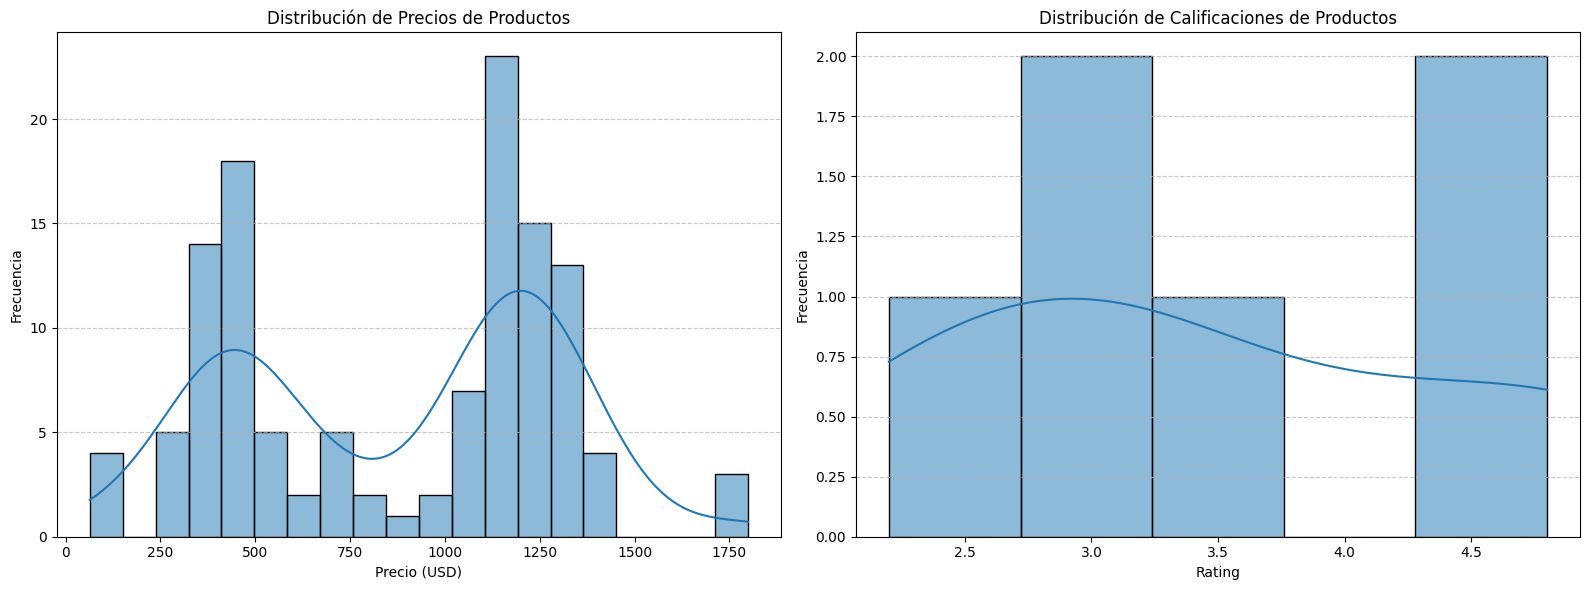

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de Precios
sns.histplot(df_maestro['precio_usd'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Precios de Productos')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Histograma de Ratings
sns.histplot(df_maestro['rating'].dropna(), bins=5, kde=True, ax=axes[1]) # dropna() para ignorar N/A
axes[1].set_title('Distribución de Calificaciones de Productos')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 📈 Comparativa de Productos (Competidor vs. Proveedor)

Estos gráficos comparan la distribución de precios y las calificaciones promedio entre los productos obtenidos del web scraping (competidor) y los de la API (proveedor). Esto permite identificar rápidamente diferencias en estrategias de precios y calidad percibida.

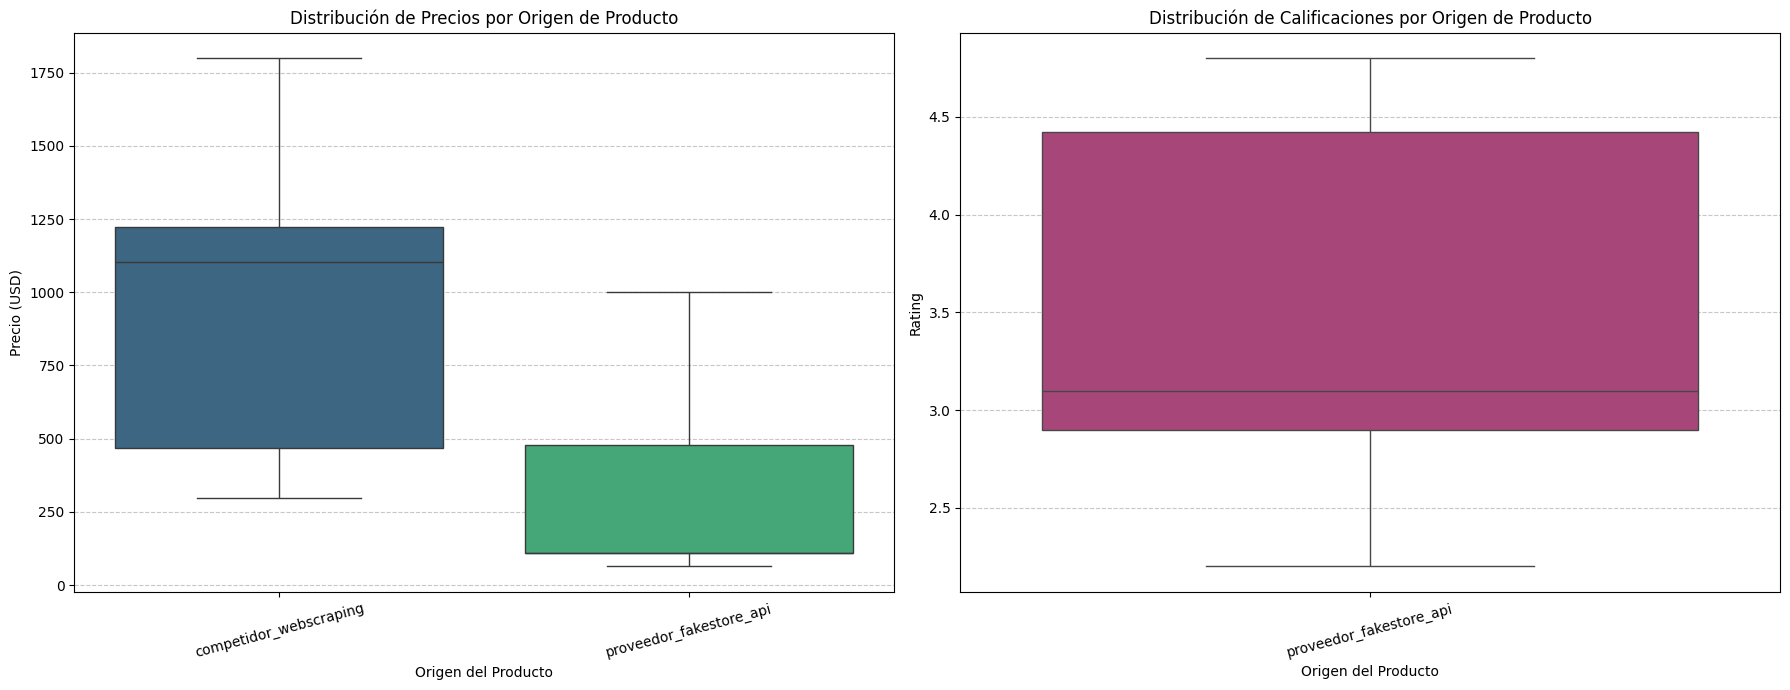

In [29]:
# Crear una figura con dos subplots para la comparación
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Comparación de Precios por Origen (Boxplot)
sns.boxplot(x='origen', y='precio_usd', data=df_maestro, ax=axes[0], hue='origen', legend=False, palette='viridis')
axes[0].set_title('Distribución de Precios por Origen de Producto')
axes[0].set_xlabel('Origen del Producto')
axes[0].set_ylabel('Precio (USD)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Comparación de Ratings por Origen (Boxplot)
# Filtrar nulos en rating para que el boxplot sea preciso
sns.boxplot(x='origen', y='rating', data=df_maestro.dropna(subset=['rating']), ax=axes[1], hue='origen', legend=False, palette='magma')
axes[1].set_title('Distribución de Calificaciones por Origen de Producto')
axes[1].set_xlabel('Origen del Producto')
axes[1].set_ylabel('Rating')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()